In [1]:
import numpy as np
import torch
from torch import nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torchvision import transforms
import torchvision.models as models
from torchvision.models import ResNet50_Weights

from rise.rise import RISE
from rise.brise import B_RISE
import rise.utils as utils
from rise.utils import IMAGES

## Model

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load pretrained weights
weights = ResNet50_Weights.DEFAULT

# Build model
model = models.resnet50(weights=weights)
model = model.to(device)
model.eval()

# Preprocessing transform
preprocess = weights.transforms()

## Init RISE

In [3]:
img_path = IMAGES / "catdog.png"
img, img_x = utils.load_image(img_path, device, preprocess)

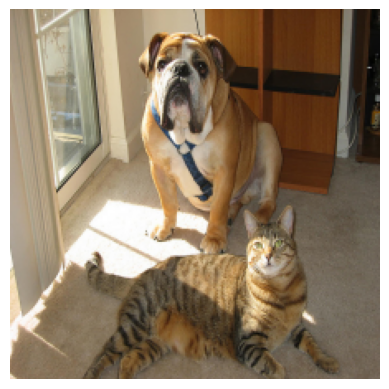

In [4]:
utils.draw_image(img)

In [5]:
rise = RISE(model, img_x)
rise.generate_masks(N=5000, s=7, p=0.1)

Generating filters: 100%|██████████| 5000/5000 [00:01<00:00, 3162.24it/s]


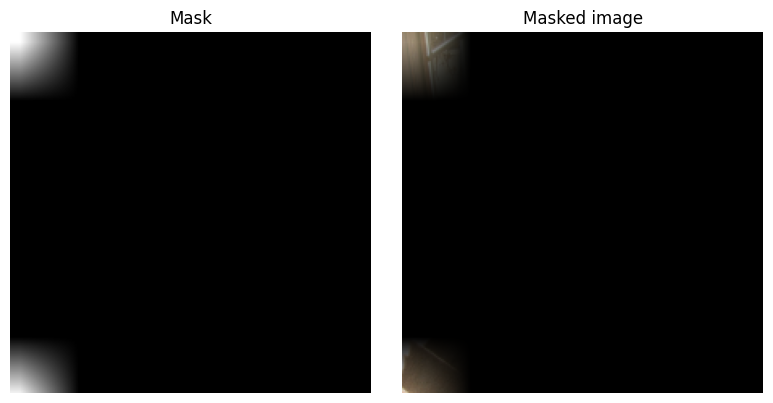

In [7]:
utils.draw_masked_image(img, rise.masks[42])

## RISE

In [8]:
topk = utils.get_topk_predictions(model, img_x, weights, k=5)
topk

[{'class_id': 243, 'class_name': 'bull mastiff', 'logit': 6.158624649047852},
 {'class_id': 281, 'class_name': 'tabby', 'logit': 3.580155611038208},
 {'class_id': 242, 'class_name': 'boxer', 'logit': 3.4773542881011963},
 {'class_id': 180,
  'class_name': 'American Staffordshire terrier',
  'logit': 3.3361282348632812},
 {'class_id': 282, 'class_name': 'tiger cat', 'logit': 3.3233225345611572}]

In [9]:
sal = rise(img_x)

Running model: 100%|██████████| 50/50 [00:05<00:00,  8.89it/s]


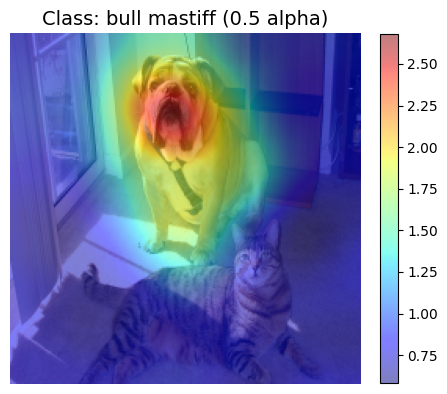

In [10]:
sal_map1 = utils.draw_saliency_overlay(img, sal, topk, k=0, norm_mode="minmax", alpha=0.5)

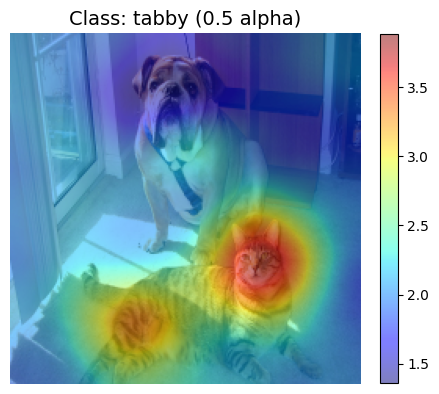

In [14]:
sal_map2 = utils.draw_saliency_overlay(img, sal, topk, k=1, norm_mode="minmax", alpha=0.5)


## Analysis of the RISE implementation


### Mask Geneeration

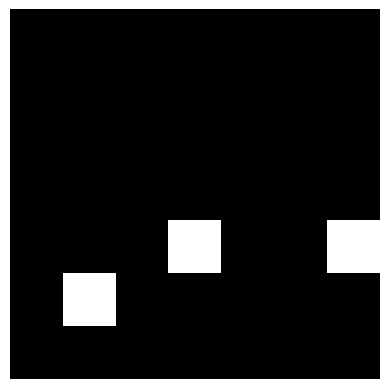

In [15]:
input_size = (img_x.shape[2], img_x.shape[3])
cell_size = np.ceil(np.array(input_size) / 7).astype(int)

grids = np.random.rand(50, 7, 7) < 0.1
grids = grids.astype('float32')

utils.draw_mask(grids[1])

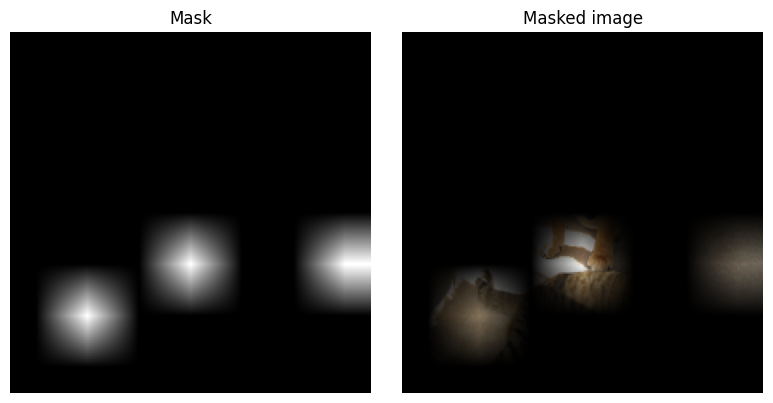

In [16]:
from rise.rise import resize_mask

up_size = 7 * cell_size   

up_mask = resize_mask(grids[1], up_size)
utils.draw_masked_image(img, up_mask.reshape(-1, input_size[0], input_size[1]))

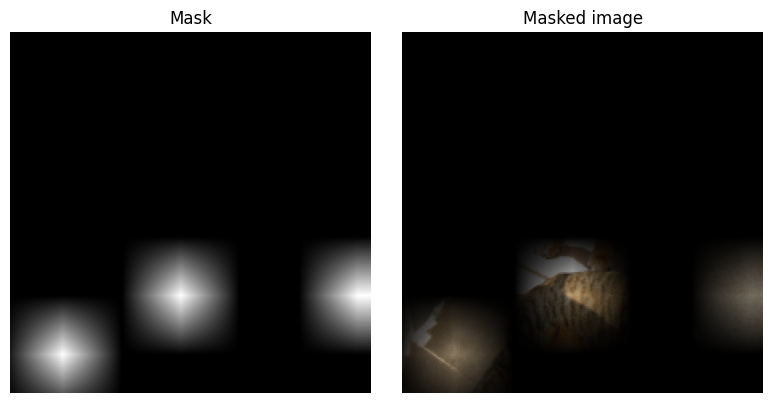

1 22


In [17]:
x = np.random.randint(0, cell_size[0])
y = np.random.randint(0, cell_size[1])

up_size = (7 + 1) * cell_size   # +1 so we can shift grids
up_mask = resize_mask(grids[1], up_size, mode='bilinear')
mask = up_mask[x:x + input_size[0],y:y + input_size[1]]
utils.draw_masked_image(img, mask.reshape(-1, input_size[0], input_size[1]))

print(x,y)

# RISE Banzhaf

In [11]:
rise_banzhaf = B_RISE(model, img_x)

In [12]:
rise_banzhaf.generate_masks(50, 7, 0.5)

In [13]:
sal = rise_banzhaf.forward(img_x)

Estimated forward passes: 1275.0


Banzhaf sampling: 100%|██████████| 50/50 [00:06<00:00,  8.22it/s]

Total forward passes: 1254


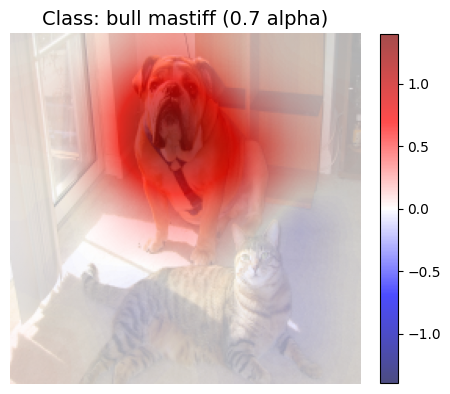

In [24]:
sal_map = utils.draw_saliency_overlay(img, sal, topk, k=0, norm_mode="symmetric", alpha=0.7)

## Another Image

In [29]:
img_path = IMAGES / "prens.png"
img, img_x = utils.load_image(img_path, device, preprocess)

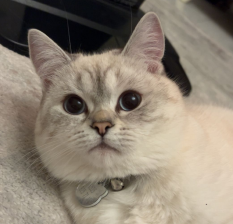

In [30]:
img

In [31]:
rise = RISE(model, img_x)
rise.generate_masks(N=4000, s=7, p=0.1)

Generating filters: 100%|██████████| 4000/4000 [00:01<00:00, 2968.63it/s]


In [32]:
sal = rise.forward(img_x)

Running model: 100%|██████████| 40/40 [00:04<00:00,  8.58it/s]


In [33]:
topk = utils.get_topk_predictions(model, img_x, weights, k=5)

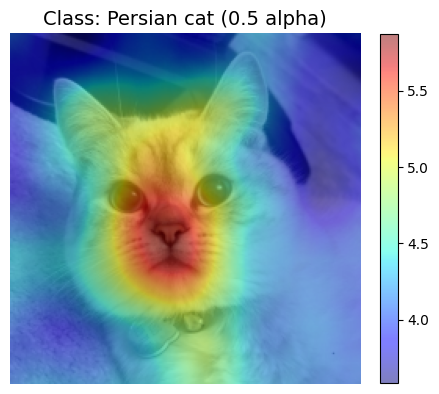

In [54]:
sal_map = utils.draw_saliency_overlay(img, sal, topk=topk, k=1, norm_mode="minmax", alpha=0.5)

In [46]:
rise_banzhaf = B_RISE(model, img_x)
rise_banzhaf.generate_masks(1000, 9, 0.5)
sal_banzhaf = rise_banzhaf.forward(img_x, K=5)

Estimated forward passes: 6000


Banzhaf sampling: 100%|██████████| 1000/1000 [00:30<00:00, 32.27it/s]

Total forward passes: 6000


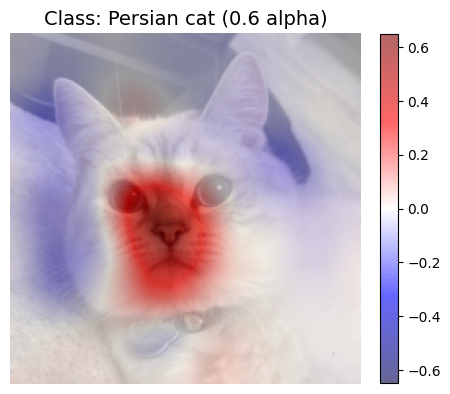

In [53]:
sal_map_banzhaf = utils.draw_saliency_overlay(img, sal_banzhaf, topk, k=1, norm_mode="symmetric", alpha=0.6)

## Another Image

In [55]:
img_path = IMAGES / "goldfish.jpg"
img, img_x = utils.load_image(img_path, device, preprocess)

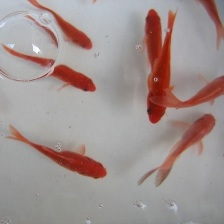

In [56]:
img

In [57]:
rise = RISE(model, img_x)
rise.generate_masks(N=5000, s=9, p=0.1)

Generating filters: 100%|██████████| 5000/5000 [00:01<00:00, 2910.54it/s]


In [58]:
sal = rise.forward(img_x)

Running model: 100%|██████████| 50/50 [00:06<00:00,  7.75it/s]


In [61]:
topk = utils.get_topk_predictions(model, img_x, weights, k=5)

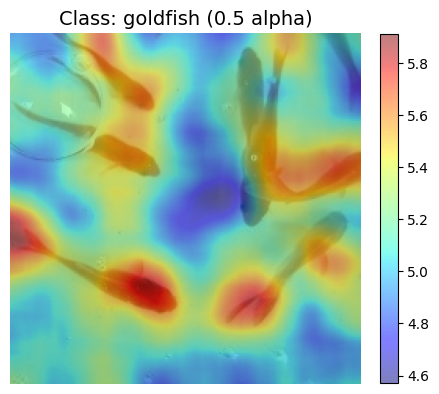

In [71]:
sal_map = utils.draw_saliency_overlay(img, sal, topk=topk, k=0, norm_mode="minmax", alpha=0.5)

In [63]:
rise_banzhaf = B_RISE(model, img_x)
rise_banzhaf.generate_masks(2000, 10, 0.1)
sal_banzhaf = rise_banzhaf.forward(img_x, K=5)

Estimated forward passes: 12000


Banzhaf sampling:   0%|          | 0/2000 [00:00<?, ?it/s]

Banzhaf sampling: 100%|██████████| 2000/2000 [01:06<00:00, 30.26it/s]

Total forward passes: 12000


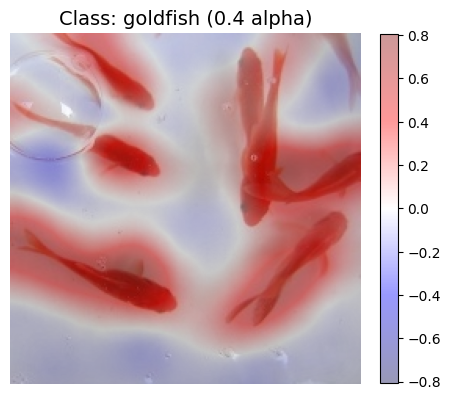

In [69]:
sal_map_banzhaf = utils.draw_saliency_overlay(img, sal_banzhaf, topk, k=0, norm_mode="symmetric", alpha=0.4)